In [18]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

In [25]:
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

### Proof of concept: simple model, Su_max changes daily

In [ ]:
# Import daily forcing data and clip
grdc_obs = pd.read_csv(
    '/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt',
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = 'date'
grdc_obs.columns = ['Observations from GRDC']

shape_area = 28191724718

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))

# Read stitched daily CSVs
p_daily_src = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
e_daily_src = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')

for frame in (p_daily_src, e_daily_src):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

p_col = 'total_precipitation_daily'
e_col = 'total_evaporation_daily'

df_p_daily = p_daily_src.set_index('time')[[p_col]].rename(columns={p_col: 'precip_m_day'})
df_e_daily = e_daily_src.set_index('time')[[e_col]].rename(columns={e_col: 'evap_m_day'})

# Convert sentinel to NaN and keep daily regularity
for frame, col in ((df_p_daily, 'precip_m_day'), (df_e_daily, 'evap_m_day')):
    frame[col] = pd.to_numeric(frame[col], errors='coerce')
    frame[col] = frame[col].replace(-9999, np.nan)

# Clip
start_ex3 = pd.Timestamp('2010-01-01')
end_ex3 = pd.Timestamp('2012-12-31')

df_p_daily = df_p_daily.loc[start_ex3:end_ex3].asfreq('D')
df_e_daily = df_e_daily.loc[start_ex3:end_ex3].asfreq('D')

# Overwrite df_p and df_e with clipped daily data for downstream use
df_p = df_p_daily.copy()
df_e = df_e_daily.copy()

print('Daily precipitation range:', df_p.index.min(), 'to', df_p.index.max(), '| n =', len(df_p))
print('Daily evaporation range:  ', df_e.index.min(), 'to', df_e.index.max(), '| n =', len(df_e))
pd.concat([df_p.head(3), df_e.head(3)], axis=1)

Daily precipitation range: 2010-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 1096
Daily evaporation range:   2010-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 1096


,precip_m_day,evap_m_day
time,,
2010-01-01,0.001517,-0.000467
2010-01-02,0.000369,-0.000267
2010-01-03,0.001446,-0.000202


In [4]:
## Daily Monte Carlo setup for hbv_bmi_project using stitched daily CSV inputs
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
from hbv_bmi_project import HBV_Bmi

# Explicit periods
start_spinup = pd.Timestamp('1980-01-01')
end_spinup = pd.Timestamp('1981-12-31')
start_cal = pd.Timestamp('1982-01-01')
end_cal = pd.Timestamp('2015-12-31')
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

start_mc = start_spinup
end_mc = end_cal

base_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Read stitched daily forcing CSVs (1980-2025), then clip to model windows
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

# Convert sentinel to NaN
precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)
temp_daily_all['temperature_2m'] = pd.to_numeric(temp_daily_all['temperature_2m'], errors='coerce').replace(-9999, np.nan)

daily_forcing = pd.DataFrame(index=pd.date_range(start_mc, end_mc, freq='D'))
daily_forcing['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing.index)
daily_forcing['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing.index)
daily_forcing['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing.index)

# Fill occasional gaps in forcing
daily_forcing['precip_m_day'] = daily_forcing['precip_m_day'].interpolate(limit_direction='both')
daily_forcing['evap_m_day'] = daily_forcing['evap_m_day'].interpolate(limit_direction='both')
daily_forcing['temp_K'] = daily_forcing['temp_K'].interpolate(limit_direction='both')

# Convert forcing to model units
daily_forcing['pr_mm_day'] = daily_forcing['precip_m_day'] * 1000.0
daily_forcing['pet_mm_day'] = (-daily_forcing['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing['temp_C'] = daily_forcing['temp_K'] - 273.15
daily_forcing['delT_C'] = daily_forcing['temp_C'] - daily_forcing['temp_C'].mean()

# Keep reusable daily temperature series for slow-dynamics/tau cells
temp_daily = (temp_daily_all['temperature_2m'] - 273.15).copy()

# Daily observed Q in mm/day (clipped to spin-up + calibration)
if 'grdc' not in globals():
    grdc = pd.read_csv(
        grdc_path_local,
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']
elif 'q_m3s' not in grdc.columns:
    grdc = grdc.copy()
    grdc.columns = ['q_m3s']

q_obs_daily = (
    grdc['q_m3s']
    .loc[start_mc:end_mc]
    .reindex(daily_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Explicit masks for spin-up, calibration, and validation periods
spinup_mask = (daily_forcing.index >= start_spinup) & (daily_forcing.index <= end_spinup)
cal_mask = (daily_forcing.index >= start_cal) & (daily_forcing.index <= end_cal)
val_mask_defined = (pd.date_range(start_val, end_val, freq='D') >= start_val)

# In-memory forcing DataArrays for hbv_bmi_project
pr_da_mc = xr.DataArray(daily_forcing['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='pr')
pet_da_mc = xr.DataArray(daily_forcing['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='evspsblpot')
tas_da_mc = xr.DataArray(daily_forcing['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='tas')

print('MC forcing period:', daily_forcing.index.min(), 'to', daily_forcing.index.max(), '| n =', len(daily_forcing))
print('Spin-up period:', start_spinup.date(), 'to', end_spinup.date(), '| n =', int(spinup_mask.sum()))
print('Calibration period:', start_cal.date(), 'to', end_cal.date(), '| n =', int(cal_mask.sum()))
print('Validation period:', start_val.date(), 'to', end_val.date())
print('Input frequency (P/PET/T/Qobs): daily')
print('delT range (C):', float(np.nanmin(daily_forcing['delT_C'])), 'to', float(np.nanmax(daily_forcing['delT_C'])))

MC forcing period: 1980-01-01 00:00:00 to 2015-12-31 00:00:00 | n = 13149
Spin-up period: 1980-01-01 to 1981-12-31 | n = 731
Calibration period: 1982-01-01 to 2015-12-31 | n = 12418
Validation period: 2016-01-01 to 2025-12-31
Input frequency (P/PET/T/Qobs): daily
delT range (C): -23.862696340454832 to 19.417905221559167


In [ ]:
# MC simulation for hbv_bmi_project (2011-2014 with 2011 warmup, score on 2012-2014)


#                      Imax, Ce, Sumax0,beta, Pmax, Tlag, Kf, Ks, Gamma
ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc = 1000
results_mc = []

obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)

    cfg = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m = HBV_Bmi()
    m.initialize(cfg)
    m.set_pars(p)

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc:
    raise RuntimeError('No valid daily MC runs found for 2011-2014.')

best_daily = max(results_mc, key=lambda d: d['nse_cal'])
sim_daily_best = best_daily['sim_mm_day']

summary_daily = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014', 'logNSE_cal_2012_2014', 'rel_bias_cal_2012_2014'],
    'value': [best_daily['nse_cal'], best_daily['lognse_cal'], best_daily['rb_cal']],
})

print('Valid runs:', len(results_mc), '/', N_mc)
print('Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily['params'])
summary_daily

Valid runs: 10000 / 10000
Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[ 6.35448246e-01  3.89032324e-01  2.05200858e+02  2.19578225e+00
  1.45937953e-01  3.05467670e+00  2.08909475e-01  3.08610827e-02
 -3.99906846e-03]


,metric,value
0,NSE_cal_2012_2014,0.845237
1,logNSE_cal_2012_2014,0.604445
2,rel_bias_cal_2012_2014,-0.045743


In [ ]:
## nse 0.814, log NSE 0.646

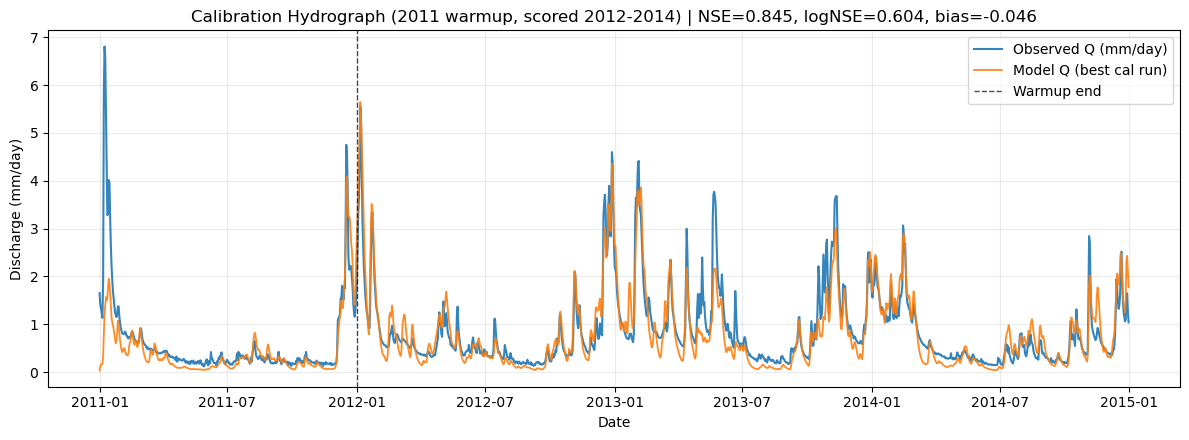

In [40]:
# Calibration hydrograph (forcing 2011-2014; metrics on 2012-2014 after warmup)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best, label='Model Q (best cal run)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('2012-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f'Calibration Hydrograph (2011 warmup, scored 2012-2014) | '
    f"NSE={best_daily['nse_cal']:.3f}, logNSE={best_daily['lognse_cal']:.3f}, bias={best_daily['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# Validation run with best calibrated parameters using stitched daily CSV inputs
start_val = pd.Timestamp('2015-01-01')
end_val = pd.Timestamp('2017-12-31')

# Load stitched daily forcing CSVs and clip to validation window
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)
temp_daily_all['temperature_2m'] = pd.to_numeric(temp_daily_all['temperature_2m'], errors='coerce').replace(-9999, np.nan)

daily_forcing_val = pd.DataFrame(index=pd.date_range(start_val, end_val, freq='D'))
daily_forcing_val['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing_val.index)

daily_forcing_val['precip_m_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both')
daily_forcing_val['evap_m_day'] = daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')
daily_forcing_val['temp_K'] = daily_forcing_val['temp_K'].interpolate(limit_direction='both')

daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'] * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing_val['temp_C'] = daily_forcing_val['temp_K'] - 273.15
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

q_obs_val = (
    grdc['q_m3s']
    .loc[start_val:end_val]
    .reindex(daily_forcing_val.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

if pd.infer_freq(daily_forcing_val.index) != 'D':
    raise ValueError('Validation forcing index is not daily.')

pr_da_val = xr.DataArray(daily_forcing_val['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='pr')
pet_da_val = xr.DataArray(daily_forcing_val['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='evspsblpot')
tas_da_val = xr.DataArray(daily_forcing_val['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='tas')

cfg_val = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val = HBV_Bmi()
m_val.initialize(cfg_val)
m_val.set_pars(best_daily['params'])

sim_val = []
while m_val.current_timestep < m_val.end_timestep:
    m_val.update()
    out = np.array([0.0])
    m_val.get_value('Q', out)
    sim_val.append(out[0])
sim_val = np.asarray(sim_val, dtype=float)

nse_val = nse(q_obs_val, sim_val)
lognse_val = log_nse(q_obs_val, sim_val)
rb_val = rel_bias(q_obs_val, sim_val)

summary_val = pd.DataFrame({
    'metric': ['NSE_val_2015_2016', 'logNSE_val_2015_2016', 'rel_bias_val_2015_2016'],
    'value': [nse_val, lognse_val, rb_val],
})

print('Validation period:', daily_forcing_val.index.min(), 'to', daily_forcing_val.index.max(), '| n =', len(daily_forcing_val))
print('Input frequency (P/PET/T/Qobs): daily')
summary_val

Validation period: 2015-01-01 00:00:00 to 2017-12-31 00:00:00 | n = 1096
Input frequency (P/PET/T/Qobs): daily


,metric,value
0,NSE_val_2015_2016,0.812120
1,logNSE_val_2015_2016,0.510934
2,rel_bias_val_2015_2016,-0.103973


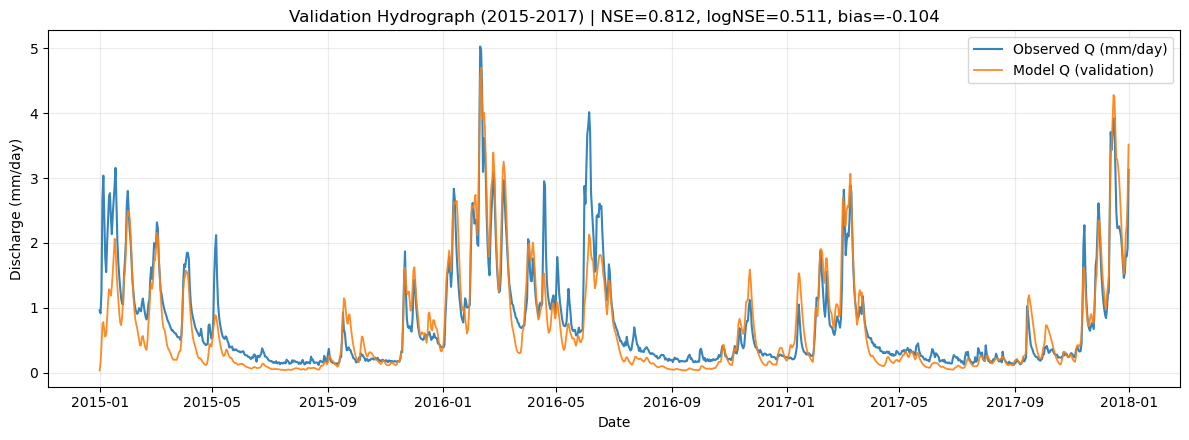

In [70]:
# Validation hydrograph
plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing_val.index, q_obs_val, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing_val.index, sim_val, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph (2015-2017) | NSE={nse_val:.3f}, logNSE={lognse_val:.3f}, bias={rb_val:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Slow-Dynamics Gamma (accounting for the "lag" in soil property change)
This section keeps HBV at daily timestep but drives `Su_max` with a **smoothed temperature anomaly** instead of raw daily temperature.

Concept:
- Keep rainfall, PET, and discharge daily.
- Replace `delT_C` with `delT_slow_C` using an exponential moving average timescale (`tau_days`).
- Calibrate and validate with the same period split to compare against the fast daily-temperature gamma setup.

I could not find existing ways to quantify the delayed response of soil to sustained temperature change. But we know that temp and SOM decomposition have a exponential relationship, so we made a conceptial modeling choice to use Exponentially Weighted Moving Average (EWMA)  as a "smoothing filter", and treat $\tau$ as a parameter calibrated during sensitivity analysis. 

In [26]:
# Build slow temperature anomaly for calibration period
if 'daily_forcing' not in globals():
    raise RuntimeError('Run the daily setup cell first so daily_forcing exists.')

tau_days = 365  # Characteristic timescale for slow soil-property response
alpha_slow = 1.0 - np.exp(-1.0 / tau_days)

daily_forcing_slow = daily_forcing.copy()
daily_forcing_slow['temp_slow_C'] = daily_forcing_slow['temp_C'].ewm(alpha=alpha_slow, adjust=False).mean()
daily_forcing_slow['delT_slow_C'] = daily_forcing_slow['temp_slow_C'] - daily_forcing_slow['temp_slow_C'].mean()

tas_da_mc_slow = xr.DataArray(
    daily_forcing_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_slow.index},
    dims=('time',),
    name='tas',
)

print('Slow-dynamics gamma setup ready.')
print('tau_days =', tau_days, '| alpha =', round(alpha_slow, 6))
print('delT_fast range:', float(daily_forcing['delT_C'].min()), 'to', float(daily_forcing['delT_C'].max()))
print('delT_slow range:', float(daily_forcing_slow['delT_slow_C'].min()), 'to', float(daily_forcing_slow['delT_slow_C'].max()))

Slow-dynamics gamma setup ready.
tau_days = 365 | alpha = 0.002736
delT_fast range: -23.862696340454832 to 19.417905221559167
delT_slow range: -11.256928764402602 to 2.7166399263137304


In [27]:
from tqdm.notebook import tqdm  # Add this import
# MC calibration using slow-dynamics gamma (same periods and bounds)
if 'cal_mask' not in globals() or 'q_obs_daily' not in globals() or 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
    raise RuntimeError('Run the daily setup cell first (it defines forcing and calibration masks).')

if 'nse' not in globals() or 'log_nse' not in globals() or 'rel_bias' not in globals():
    raise RuntimeError('Run the MC metric-definition cell first (nse/log_nse/rel_bias).')

# Reuse current bounds if present; otherwise define defaults
if 'ParMinn_mc' not in globals() or 'ParMaxn_mc' not in globals():
    ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
    ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc_slow = 1000
results_mc_slow = []
obs_cal = q_obs_daily[cal_mask]

# Add progress bar to the loop
for _ in tqdm(range(N_mc_slow), desc="Monte Carlo Calibration", unit="run"):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
    cfg_slow = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc_slow,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m_slow = HBV_Bmi()
    m_slow.initialize(cfg_slow)
    m_slow.set_pars(p)

    sim = []
    while m_slow.current_timestep < m_slow.end_timestep:
        m_slow.update()
        out = np.array([0.0])
        m_slow.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc_slow.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc_slow:
    raise RuntimeError('No valid slow-gamma MC runs found.')

best_daily_slow = max(results_mc_slow, key=lambda d: d['nse_cal'])
sim_daily_best_slow = best_daily_slow['sim_mm_day']

summary_daily_slow = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014_slowGamma', 'logNSE_cal_2012_2014_slowGamma', 'rel_bias_cal_2012_2014_slowGamma'],
    'value': [best_daily_slow['nse_cal'], best_daily_slow['lognse_cal'], best_daily_slow['rb_cal']],
})

print('Valid slow-gamma runs:', len(results_mc_slow), '/', N_mc_slow)
print('Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily_slow['params'])
summary_daily_slow

Monte Carlo Calibration:   0%|          | 0/1000 [00:00<?, ?run/s]

Valid slow-gamma runs: 1000 / 1000
Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[1.97199649e-01 3.31142575e-01 2.28280540e+02 1.90141574e+00
 3.88264141e-02 2.84130435e+00 2.50533547e-01 9.94632373e-03
 1.75406666e-02]


,metric,value
0,NSE_cal_2012_2014_slowGamma,0.858568
1,logNSE_cal_2012_2014_slowGamma,0.188485
2,rel_bias_cal_2012_2014_slowGamma,-0.151268


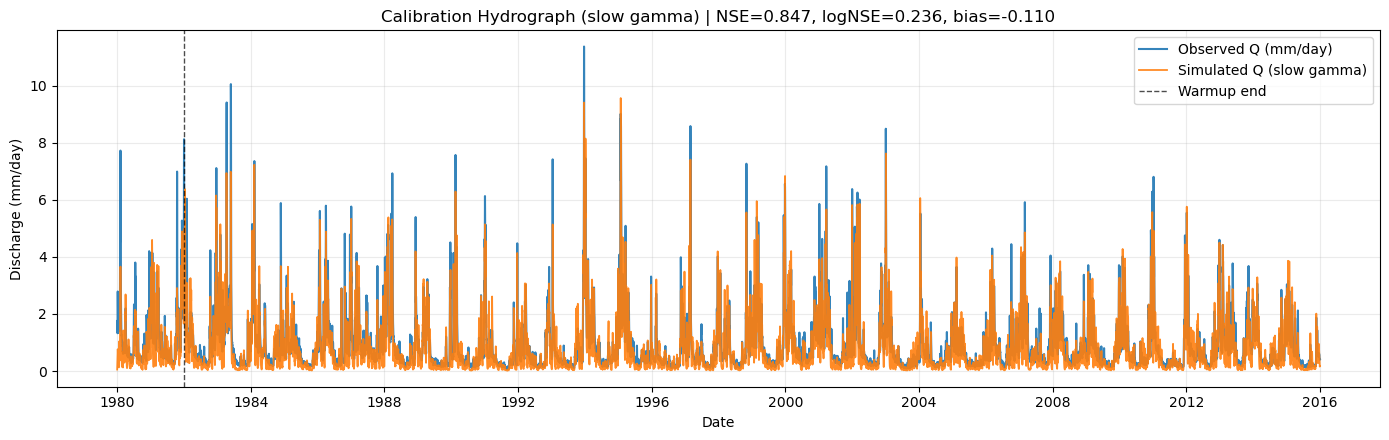

In [57]:
# Plot observed vs simulated calibration values for the slow-dynamics gamma run
import matplotlib.pyplot as plt

if 'daily_forcing' not in globals() or 'q_obs_daily' not in globals() or 'sim_daily_best_slow' not in globals():
    raise RuntimeError('Run the slow-gamma calibration setup cell first so daily_forcing, q_obs_daily, and sim_daily_best_slow exist.')

plt.figure(figsize=(14, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best_slow, label='Simulated Q (slow gamma)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('1982-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f"Calibration Hydrograph (slow gamma) | NSE={best_daily_slow['nse_cal']:.3f}, "
    f"logNSE={best_daily_slow['lognse_cal']:.3f}, bias={best_daily_slow['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
# Validation with slow-dynamics gamma (same validation period)
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

daily_forcing_val = pd.DataFrame(index=pd.date_range(start_val, end_val, freq='D'))
daily_forcing_val['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing_val.index)

daily_forcing_val['precip_m_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both')
daily_forcing_val['evap_m_day'] = daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')
daily_forcing_val['temp_K'] = daily_forcing_val['temp_K'].interpolate(limit_direction='both')

daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'] * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing_val['temp_C'] = daily_forcing_val['temp_K'] - 273.15
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

# Build slow temperature over a longer continuous index to avoid edge effects at validation start
slow_full_index = pd.date_range(start=daily_forcing.index.min(), end=daily_forcing_val.index.max(), freq='D')
temp_full = temp_daily.reindex(slow_full_index).interpolate(limit_direction='both')
temp_slow_full = temp_full.ewm(alpha=alpha_slow, adjust=False).mean()
temp_slow_val = temp_slow_full.reindex(daily_forcing_val.index)

daily_forcing_val_slow = daily_forcing_val.copy()
daily_forcing_val_slow['temp_slow_C'] = temp_slow_val.to_numpy()
daily_forcing_val_slow['delT_slow_C'] = daily_forcing_val_slow['temp_slow_C'] - daily_forcing_val_slow['temp_slow_C'].mean()

tas_da_val_slow = xr.DataArray(
    daily_forcing_val_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_val_slow.index},
    dims=('time',),
    name='tas',
)

cfg_val_slow = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val_slow,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val_slow = HBV_Bmi()
m_val_slow.initialize(cfg_val_slow)
m_val_slow.set_pars(best_daily_slow['params'])

sim_val_slow = []
while m_val_slow.current_timestep < m_val_slow.end_timestep:
    m_val_slow.update()
    out = np.array([0.0])
    m_val_slow.get_value('Q', out)
    sim_val_slow.append(out[0])
sim_val_slow = np.asarray(sim_val_slow, dtype=float)

nse_val_slow = nse(q_obs_val, sim_val_slow)
lognse_val_slow = log_nse(q_obs_val, sim_val_slow)
rb_val_slow = rel_bias(q_obs_val, sim_val_slow)

summary_val_slow = pd.DataFrame({
    'metric': ['NSE_val_slowGamma', 'logNSE_val_slowGamma', 'rel_bias_val_slowGamma'],
    'value': [nse_val_slow, lognse_val_slow, rb_val_slow],
})

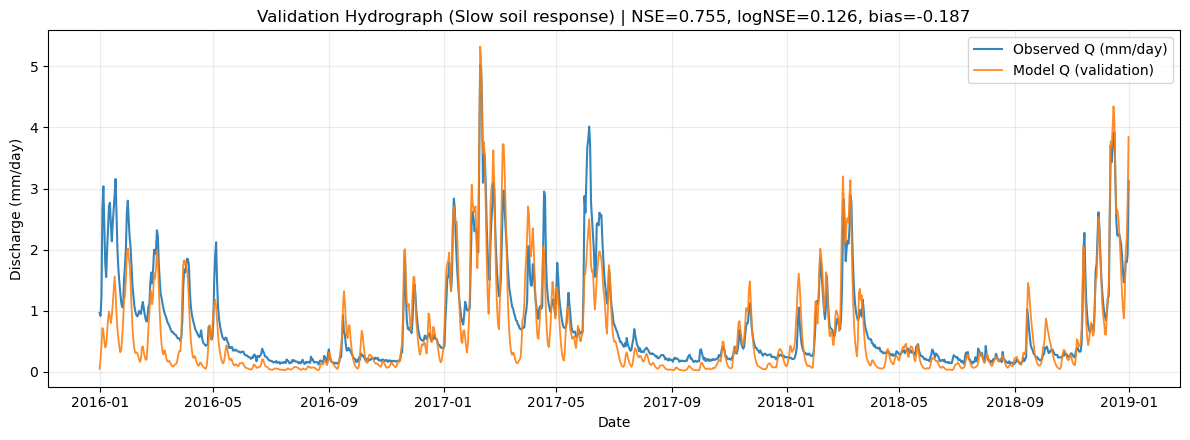

In [89]:
# Validation hydrograph
n_plot = min(len(daily_forcing_val.index), len(q_obs_val), len(sim_val_slow))
plot_index = daily_forcing_val.index[:n_plot]
plot_obs = q_obs_val[:n_plot]
plot_sim = sim_val_slow[:n_plot]

plt.figure(figsize=(12, 4.5))
plt.plot(plot_index, plot_obs, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(plot_index, plot_sim, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph (Slow soil response) | NSE={nse_val_slow:.3f}, logNSE={lognse_val_slow:.3f}, bias={rb_val_slow:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

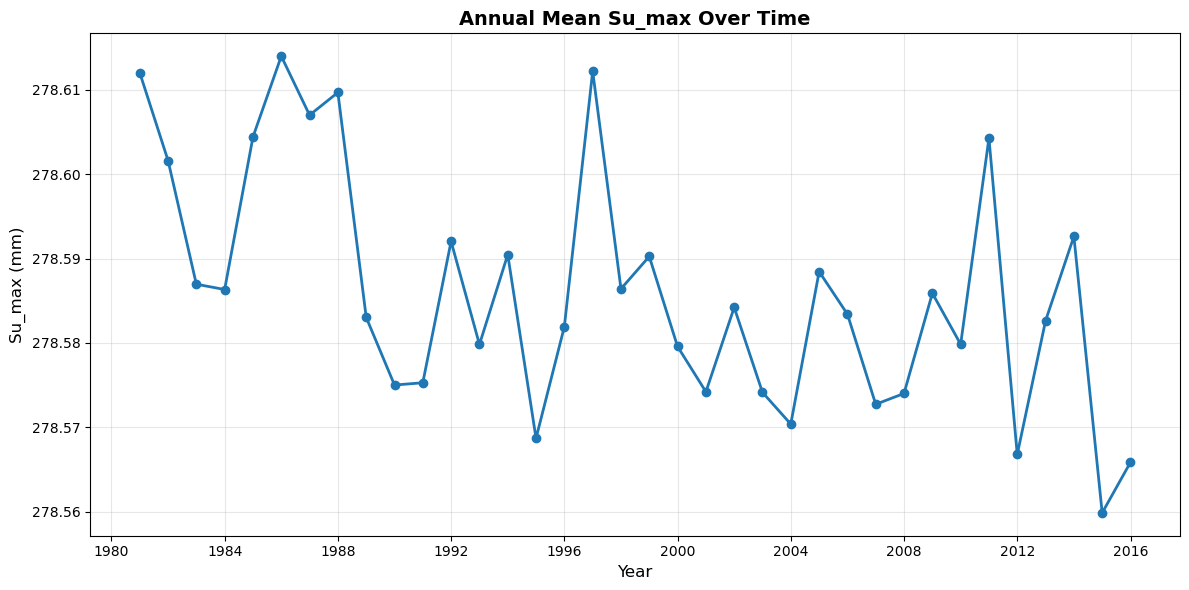

In [15]:
# plot Su_max against delta temperature 

# best_Sumax0 = best_daily_slow['params'][2]
# best_gamma = best_daily_slow['params'][8]

best_Sumax0 = 278.586
best_gamma = -0.019167

tests = daily_forcing.copy()
tests['ts_Sumax'] = best_Sumax0 + best_gamma * daily_forcing['delT_C']

# Calculate annual means
annual_means = tests['ts_Sumax'].resample("YE").mean()

# Plot annual means against time (not against daily index)
plt.figure(figsize=(12, 6))
plt.plot(annual_means.index, annual_means.values, 'o-', linewidth=2, markersize=6)
plt.xlabel('Year', fontsize=12)
plt.ylabel("Su_max (mm)", fontsize=12)
plt.title('Annual Mean Su_max Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Tau Sensitivity Analysis (Slow-Dynamics Gamma)
This tests slow-temperature response timescales: 180, 365, 730, 1825 days.

Method:
- Use the same calibration period and validation period.
- Reuse the same random parameter samples for all tau values (fair comparison).
- For each tau, select the best parameter set by calibration NSE and evaluate validation metrics.

In [ ]:
# Tau sensitivity analysis for slow-dynamics gamma
tau_list = [180, 365, 730, 1825]  # 6 months, 1 year, 2 years, 5 years

required = ['daily_forcing', 'daily_forcing_val', 'pr_da_mc', 'pet_da_mc', 'pr_da_val', 'pet_da_val', 'q_obs_daily', 'q_obs_val', 'cal_mask', 'ParMinn_mc', 'ParMaxn_mc']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Missing prerequisites: {missing}. Run main setup/calibration/validation cells first.')

# Ensure metrics are defined
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

# Ensure daily temperature source exists (from stitched daily CSV)
if 'temp_daily' not in globals():
    temp_daily_src = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')
    temp_daily_src['time'] = pd.to_datetime(temp_daily_src['system:index'].astype(str), format='%Y%m%d')
    temp_daily = pd.to_numeric(temp_daily_src['temperature_2m'], errors='coerce').replace(-9999, np.nan) - 273.15
    temp_daily.index = temp_daily_src['time']

# Use same random parameter samples for all tau values (fair comparison)
N_mc_tau = 1000
rng = np.random.default_rng(42)
param_samples = rng.uniform(ParMinn_mc, ParMaxn_mc, size=(N_mc_tau, len(ParMinn_mc)))

obs_cal = q_obs_daily[cal_mask]
tau_results = []

for tau_days in tau_list:
    alpha_tau = 1.0 - np.exp(-1.0 / tau_days)

    # Calibration slow temperature
    temp_slow_cal = daily_forcing['temp_C'].ewm(alpha=alpha_tau, adjust=False).mean()
    delT_slow_cal = temp_slow_cal - temp_slow_cal.mean()
    tas_da_mc_tau = xr.DataArray(delT_slow_cal.to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='tas')

    # Validation slow temperature: smooth over continuous period to reduce edge effects
    slow_full_index = pd.date_range(start=daily_forcing.index.min(), end=daily_forcing_val.index.max(), freq='D')
    temp_full = temp_daily.reindex(slow_full_index).interpolate(limit_direction='both')
    temp_slow_full = temp_full.ewm(alpha=alpha_tau, adjust=False).mean()
    temp_slow_val = temp_slow_full.reindex(daily_forcing_val.index)
    delT_slow_val = temp_slow_val - temp_slow_val.mean()
    tas_da_val_tau = xr.DataArray(delT_slow_val.to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='tas')

    best_tau = None
    valid_runs = 0

    for p in param_samples:
        cfg_tau = {
            'precipitation_file': pr_da_mc,
            'potential_evaporation_file': pet_da_mc,
            'temperature_file': tas_da_mc_tau,
            'T_baseline': 0.0,
            'initial_storage': '0.0,100.0,0.0,5.0',
        }
        m_tau = HBV_Bmi()
        m_tau.initialize(cfg_tau)
        m_tau.set_pars(p)

        sim = []
        while m_tau.current_timestep < m_tau.end_timestep:
            m_tau.update()
            out = np.array([0.0])
            m_tau.get_value('Q', out)
            sim.append(out[0])
        sim = np.asarray(sim, dtype=float)

        if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
            continue

        valid_runs += 1
        sim_cal = sim[cal_mask]
        nse_cal = nse(obs_cal, sim_cal)
        if not np.isfinite(nse_cal):
            continue

        if (best_tau is None) or (nse_cal > best_tau['nse_cal']):
            best_tau = {
                'params': p.copy(),
                'sim_cal_full': sim,
                'nse_cal': nse_cal,
                'lognse_cal': log_nse(obs_cal, sim_cal),
                'rb_cal': rel_bias(obs_cal, sim_cal),
            }

    if best_tau is None:
        tau_results.append({
            'tau_days': tau_days,
            'valid_runs': valid_runs,
            'nse_cal': np.nan,
            'lognse_cal': np.nan,
            'rb_cal': np.nan,
            'nse_val': np.nan,
            'lognse_val': np.nan,
            'rb_val': np.nan,
            'gamma': np.nan,
        })
        continue

    # Validation with best params for this tau
    cfg_val_tau = {
        'precipitation_file': pr_da_val,
        'potential_evaporation_file': pet_da_val,
        'temperature_file': tas_da_val_tau,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }
    m_val_tau = HBV_Bmi()
    m_val_tau.initialize(cfg_val_tau)
    m_val_tau.set_pars(best_tau['params'])

    sim_val_tau = []
    while m_val_tau.current_timestep < m_val_tau.end_timestep:
        m_val_tau.update()
        out = np.array([0.0])
        m_val_tau.get_value('Q', out)
        sim_val_tau.append(out[0])
    sim_val_tau = np.asarray(sim_val_tau, dtype=float)

    tau_results.append({
        'tau_days': tau_days,
        'valid_runs': valid_runs,
        'nse_cal': best_tau['nse_cal'],
        'lognse_cal': best_tau['lognse_cal'],
        'rb_cal': best_tau['rb_cal'],
        'nse_val': nse(q_obs_val, sim_val_tau),
        'lognse_val': log_nse(q_obs_val, sim_val_tau),
        'rb_val': rel_bias(q_obs_val, sim_val_tau),
        'gamma': float(best_tau['params'][8]),
    })

tau_sensitivity_df = pd.DataFrame(tau_results).sort_values('tau_days').reset_index(drop=True)
tau_sensitivity_df

,tau_days,valid_runs,nse_cal,lognse_cal,rb_cal,nse_val,lognse_val,rb_val,gamma
0,180,1000,0.820442,0.718517,0.034686,0.638723,0.316203,-0.185995,-0.022896
1,365,1000,0.820376,0.718470,0.034752,0.638704,0.316180,-0.185954,-0.022896
2,730,1000,0.820342,0.718446,0.034777,0.638684,0.316142,-0.185931,-0.022896
3,1825,1000,0.820327,0.718435,0.034765,0.638670,0.316113,-0.185915,-0.022896


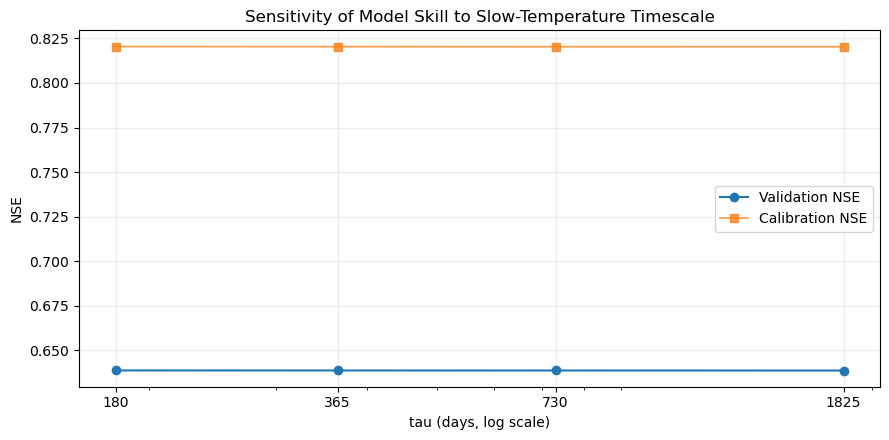

In [29]:
# Quick visual ranking by validation NSE
plot_df = tau_sensitivity_df.dropna(subset=['nse_val']).copy()
plot_df = plot_df.sort_values('tau_days')

plt.figure(figsize=(9, 4.5))
plt.plot(plot_df['tau_days'], plot_df['nse_val'], marker='o', linewidth=1.5, label='Validation NSE')
plt.plot(plot_df['tau_days'], plot_df['nse_cal'], marker='s', linewidth=1.2, label='Calibration NSE', alpha=0.8)
plt.xscale('log')
plt.xticks([180, 365, 730, 1825], ['180', '365', '730', '1825'])
plt.xlabel('tau (days, log scale)')
plt.ylabel('NSE')
plt.title('Sensitivity of Model Skill to Slow-Temperature Timescale')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
### project for future temperature scenarios - calculate discharge using new temp, evap and precipitation 
### smaller Su_max = less groundwater recharge? 

In [ ]:
### compute flow duration curve, and see whether flow has increased or decreased 

In [ ]:
### for each decade, place the long term average of the basin on the budyko framework. But we need potential evaporation. 
### also calculate Ea/Ep, the crop water stress index.

## If we can't find anything, we can calculate PET using the penmann-monteith equation 